In [1]:
import pandas as pd

from multimodal_fin.financial.pipeline import EventPipeline
from multimodal_fin.financial.event import Event
from multimodal_fin.financial.price_preprocessor import PricePreprocessor
from multimodal_fin.financial.analysis import analyze_statistical_significance, plot_AR_significance

from multimodal_fin.utils.logging import get_logger

In [2]:
logger = get_logger("events_study")

price_file = "/home/aacastro/2025_ACA_MultichannelAI/data/financial/price_2019_2025.csv"
companies_folder = "/home/aacastro/2025_ACA_MultichannelAI/data/financial/companies_closes"
conference_file = "/home/aacastro/2025_ACA_MultichannelAI/data/financial/conference_data.csv"

In [3]:
preprocessor = PricePreprocessor(price_file, companies_folder)
tickers = preprocessor.split_by_ticker()

2025-09-21 16:31:06 - multimodal_fin.financial.price_preprocessor - INFO - Loading master price file: /home/aacastro/2025_ACA_MultichannelAI/data/financial/price_2019_2025.csv
2025-09-21 16:31:06 - multimodal_fin.financial.price_preprocessor - INFO - Found 217 unique tickers.
2025-09-21 16:31:10 - multimodal_fin.financial.price_preprocessor - INFO - Finished splitting dataset into 217 CSV files.


# Obtain events study from a single conference

2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 12.5729%



📅 Event: 2024-10-31 (AMZN)
Alpha: 0.001975
Beta: 0.688960
CAR [-7, 7]: 12.5729%


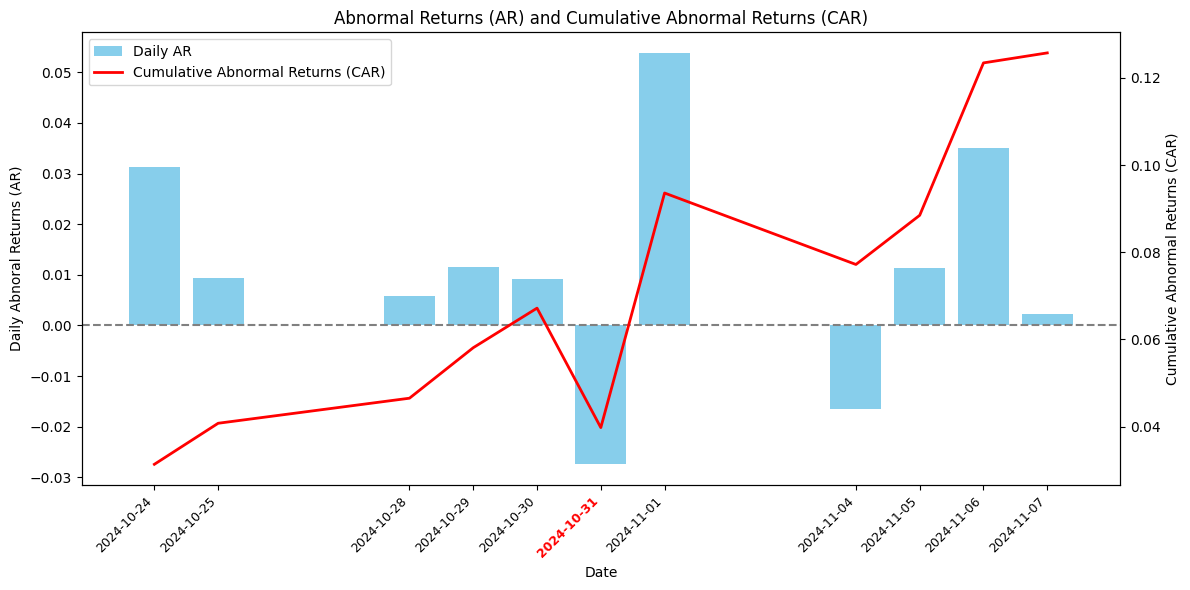

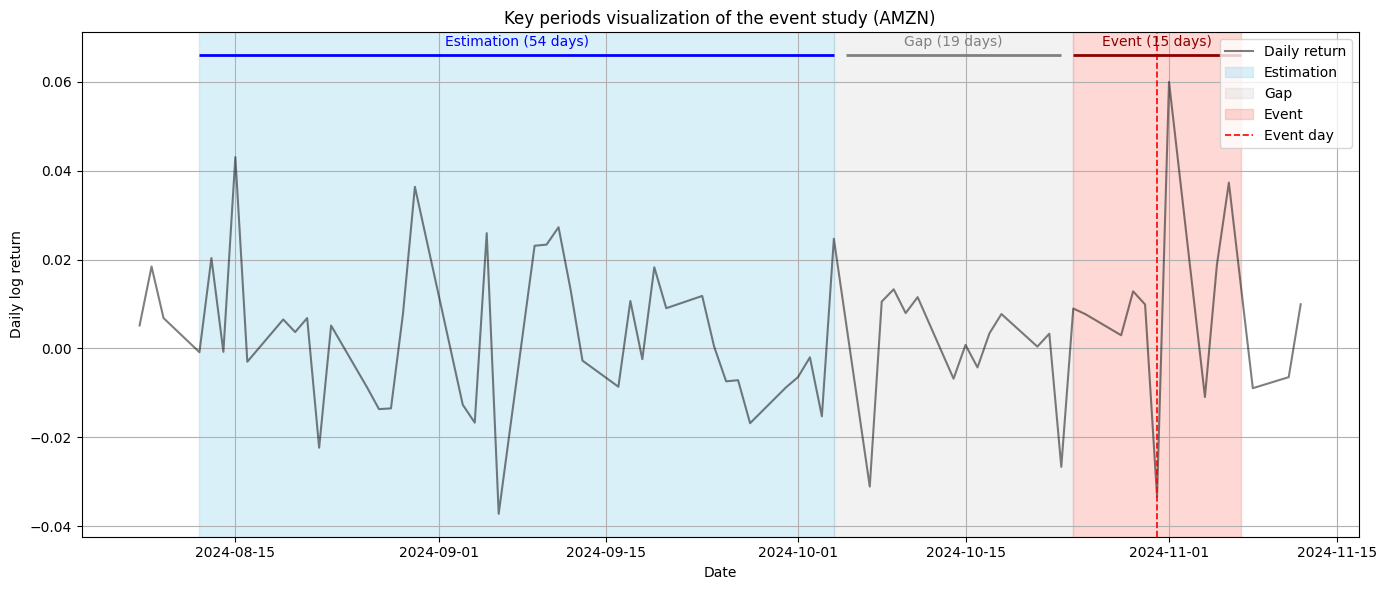

In [4]:
event = Event(
    event_date="2024-10-31",
    ticker="AMZN",
    plot_flags={"returns": True, "car": True},
    folder_path="/home/aacastro/2025_ACA_MultichannelAI/data/financial/companies_closes"
)

event.summary()

# Process multiple conferences filtering by company

In [5]:
pipeline = EventPipeline(conference_file=conference_file, folder_path=companies_folder)
events = pipeline.run(ticker_filter="AMZN")

2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 7.6684%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = -10.2734%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 0.4883%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = -0.3585%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = -10.5535%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 12.5729%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 9.7128%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = 7.9927%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for AMZN | CAR = -0.9422%
2025-09-21 16:31:10 -

# Statistical evidence

In this case, although the sample is not very large, we could conclude here that there is no evidence that the events have a systematic effect on the cumulative return within this window

2025-09-21 16:31:10 - multimodal_fin.financial.analysis - INFO - CAR mean in window (-7, 7): -1.0871% (t-stat=-0.449, p-value=0.65769, n_samples=22)



             t   mean_AR    std_AR    t_stat   p_value   n
0  CAR_window -0.010871  0.113437 -0.449482  0.657689  22


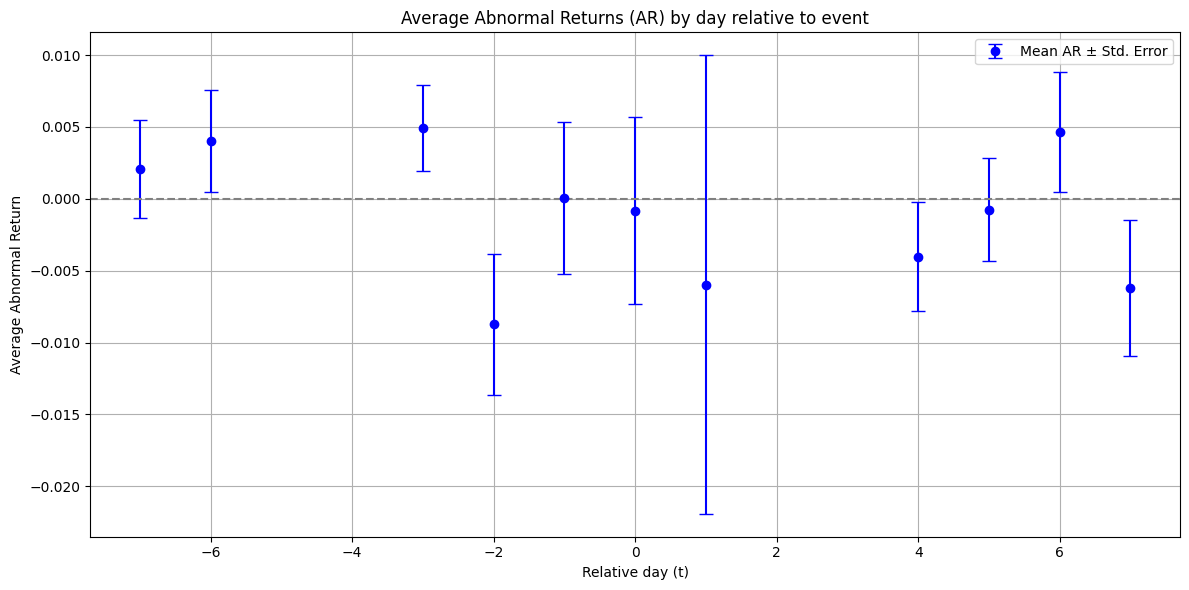

In [6]:
df_stats, summary  = analyze_statistical_significance(events, car_window=(-7, 7))

print("\n", summary )

plot_AR_significance(df_stats, alpha=0.05)

This chart shows average abnormal returns (AR) by day relative to the event, with error bars as standard errors.


We see small positive ARs before the event and more volatile, negative ARs around the event day.
It suggests some anticipation effect but high variability, meaning market reactions are not consistently significant.

# Companies with Statistical Evidence of Price Impact

In [7]:
summaries = []

for ticker in tickers[5:]:
    try:
        pipeline = EventPipeline(conference_file=conference_file, folder_path=companies_folder)
        events = pipeline.run(ticker_filter=ticker)

        # print(len(events))

        if len(events) <= 1:
            logger.warning(f"No events found for ticker {ticker}. Skipping...")
            continue

        df_stats, summary = analyze_statistical_significance(events, car_window=(-7, 7))

        # añadir ticker para identificar luego
        summary["ticker"] = ticker
        summaries.append(summary)

    except Exception as e:
        logger.error(f"Error analyzing ticker {ticker}: {str(e)}")
        continue

df_summaries = pd.concat(summaries, ignore_index=True) if summaries else pd.DataFrame()

2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = -3.4336%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = 6.7162%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = 3.0843%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = -15.4018%


2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = -1.9490%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = 7.3595%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = -5.1886%
2025-09-21 16:31:10 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = -1.6165%
2025-09-21 16:31:11 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = -1.0451%
2025-09-21 16:31:11 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = 1.4848%
2025-09-21 16:31:11 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = 1.0571%
2025-09-21 16:31:11 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = 10.4927%
2025-09-21 16:31:11 - multimodal_fin.financial.event - INFO - Finished event study for ADP | CAR = -3.3284%
2025-09-21 16:31:11 - multimoda

In [8]:
df = df_summaries.rename(columns={
    "mean_AR": "CAR_mean",
    "std_AR": "CAR_std",
    "t_stat": "t_statistic",
    "p_value": "p_value",
    "n": "n_events"
})

ticker_to_name = {
    "ETN": "Eaton Corporation",
    "IFF": "International Flavors & Fragrances",
    "KO": "The Coca-Cola Company",
    "MLM": "Martin Marietta Materials",
    "NEM": "Newmont Corporation",
    "PH": "Parker-Hannifin Corporation",
    "SPG": "Simon Property Group",
    "TT": "Trane Technologies"
}

df["company_name"] = df["ticker"].map(ticker_to_name)

df["significant"] = df["p_value"] < 0.05
df["effect_direction"] = df["CAR_mean"].apply(lambda x: "Positive" if x > 0 else "Negative")
df["effect_magnitude_%"] = df["CAR_mean"] * 100

df_sorted = df.sort_values(by="p_value")

def summarize(row):
    if row["significant"]:
        return f"{row['ticker']}: {row['effect_direction']} significant effect ({row['effect_magnitude_%']:.2f}%)"
    else:
        return f"{row['ticker']}: No significant effect"

df["conclusion"] = df.apply(summarize, axis=1)

In [9]:
df[df["significant"]]

,t,CAR_mean,CAR_std,t_statistic,p_value,n_events,ticker,company_name,significant,effect_direction,effect_magnitude_%,conclusion
64,CAR_window,0.046090,0.042512,4.848504,0.000112,20,ETN,Eaton Corporation,True,Positive,4.608985,ETN: Positive significant effect (4.61%)
86,CAR_window,-0.096446,0.112472,-2.425400,0.045728,8,IFF,International Flavors & Fragrances,True,Negative,-9.644585,IFF: Negative significant effect (-9.64%)
99,CAR_window,0.022479,0.032756,3.144759,0.005099,21,KO,The Coca-Cola Company,True,Positive,2.247868,KO: Positive significant effect (2.25%)
114,CAR_window,0.048577,0.056724,3.204263,0.006911,14,MLM,Martin Marietta Materials,True,Positive,4.857726,MLM: Positive significant effect (4.86%)
126,CAR_window,-0.047988,0.080693,-2.303231,0.037122,15,NEM,Newmont Corporation,True,Negative,-4.798763,NEM: Negative significant effect (-4.80%)
145,CAR_window,0.057091,0.076738,3.409312,0.002781,21,PH,Parker-Hannifin Corporation,True,Positive,5.709062,PH: Positive significant effect (5.71%)
163,CAR_window,0.038485,0.050449,2.750478,0.017587,13,SPG,Simon Property Group,True,Positive,3.848490,SPG: Positive significant effect (3.85%)
178,CAR_window,0.036828,0.057530,2.639397,0.017851,17,TT,Trane Technologies,True,Positive,3.682761,TT: Positive significant effect (3.68%)
